L2 Norm of Overfit Model Weights: 663510.3691
L2 Norm of Regularized Model Weights: 17.5990


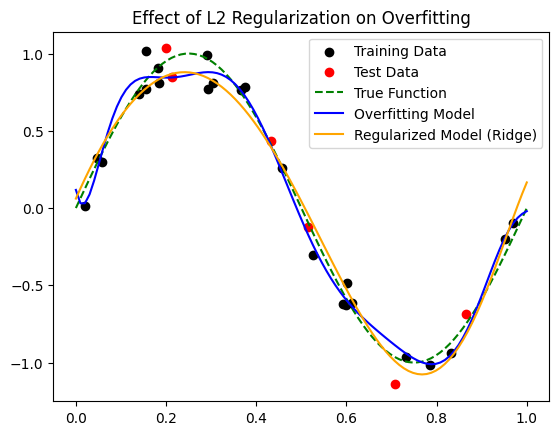

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Generate synthetic data
def true_function(x):
    return np.sin(2 * np.pi * x)

np.random.seed(42)
x = np.sort(np.random.rand(30))  # 30 random points
y = true_function(x) + np.random.normal(scale=0.1, size=x.shape)  # Add noise

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_test = x_train.reshape(-1, 1), x_test.reshape(-1, 1)

# Overfitting Model (High-degree polynomial without regularization)
overfit_model = make_pipeline(PolynomialFeatures(degree=10), LinearRegression())
overfit_model.fit(x_train, y_train)

# Regularized Model (Ridge Regression with L2 norm penalty)
simple_model = make_pipeline(PolynomialFeatures(degree=10), Ridge(alpha=0.001))
simple_model.fit(x_train, y_train)

# Compute L2 norms
complex_weights = overfit_model.named_steps['linearregression'].coef_
simple_weights = simple_model.named_steps['ridge'].coef_

l2_norm_complex = np.linalg.norm(complex_weights)
l2_norm_simple = np.linalg.norm(simple_weights)

print(f"L2 Norm of Overfit Model Weights: {l2_norm_complex:.4f}")
print(f"L2 Norm of Regularized Model Weights: {l2_norm_simple:.4f}")

# Plot results
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)
y_overfit = overfit_model.predict(x_plot)
y_simple = simple_model.predict(x_plot)

def plot_results():
    plt.scatter(x_train, y_train, label="Training Data", color='black')
    plt.scatter(x_test, y_test, label="Test Data", color='red')
    plt.plot(x_plot, true_function(x_plot), label="True Function", linestyle='dashed', color='green')
    plt.plot(x_plot, y_overfit, label="Overfitting Model", color='blue')
    plt.plot(x_plot, y_simple, label="Regularized Model (Ridge)", color='orange')
    plt.legend()
    plt.title("Effect of L2 Regularization on Overfitting")
    plt.show()

plot_results()